# Numerov method: particle in a box
Solves $\psi'' = -2E\psi$ ($\hbar = m = 1$) on $[-L, L]$ with $\psi(\pm L)=0$, using the **shooting method**: integrate from the left wall with Numerov, then tune $E$ until $\psi$ vanishes at the right wall.

Exact result for comparison: $E_n = n^2\pi^2 / (8L^2)$.

Interactive sliders need an interactive backend: run `%matplotlib widget` (ipympl) or `%matplotlib qt` first.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

In [12]:
L = 2
Npoints = 1000
Estep = 0.05      # coarse energy step used to bracket a sign change
accuracy = 1e-4   # tolerance on psi(right wall)
Nlevels = 5

In [13]:
def numerov(E, dx):
    """Integrate psi'' = -2E psi from the left wall; return normalized psi."""
    psi = np.zeros(Npoints)
    psi[1] = 1.0                      # arbitrary slope, fixed by normalization
    c = dx*dx*E/6
    for k in range(2, Npoints):
        phi1 = psi[k-1]*(1 + c)
        phi2 = psi[k-2]*(1 + c)
        psi[k] = (2*phi1 - phi2 - 2*dx*dx*E*psi[k-1]) / (1 + c)
    norm = np.sqrt(np.trapezoid(psi**2, dx=dx))
    return psi / norm

def bisect(f, a, b):
    """Zero of f in [a, b]; assumes f(a) and f(b) have opposite signs."""
    fa = f(a)
    while True:
        m = (a + b)/2
        fm = f(m)
        if abs(fm) < accuracy:
            return m
        if fa*fm > 0:
            a, fa = m, fm
        else:
            b = m

def find_levels(L, nlevels):
    xs = np.linspace(-L, L, Npoints)
    dx = xs[1] - xs[0]                # = 2L/(Npoints-1), consistent with the grid
    levels, E0 = [], Estep
    for _ in range(nlevels):
        # bracket: step E until psi(right wall) changes sign
        E2 = E0
        prev = cur = numerov(E2, dx)[-1]
        while prev*cur > 0:
            prev, E2 = cur, E2 + Estep
            cur = numerov(E2, dx)[-1]
        E = bisect(lambda e: numerov(e, dx)[-1], E2 - Estep, E2)
        levels.append((E, numerov(E, dx)))
        E0 = E + Estep
    return xs, levels

E0 = 0.3084   (exact 0.3084)
E1 = 1.2337   (exact 1.2337)
E2 = 2.7759   (exact 2.7758)
E3 = 4.9349   (exact 4.9348)
E4 = 7.7106   (exact 7.7106)


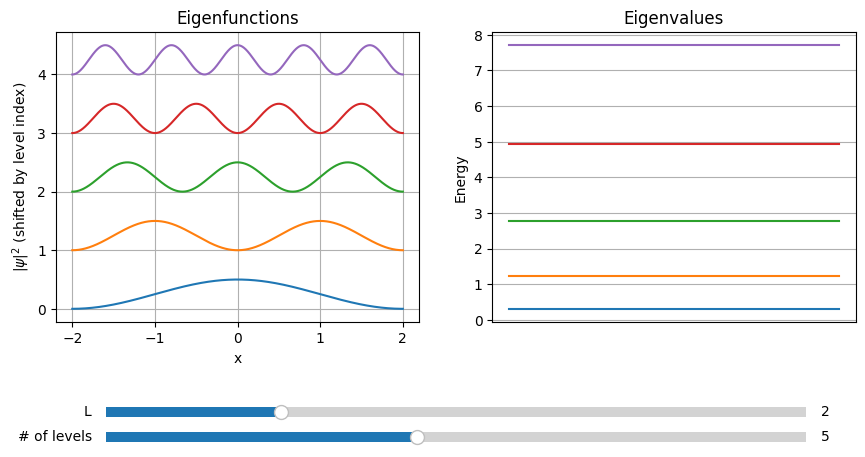

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
plt.subplots_adjust(left=0.1, bottom=0.3)

def style():
    ax1.set(xlabel='x', ylabel=r'$|\psi|^2$ (shifted by level index)', title='Eigenfunctions')
    ax1.grid()
    ax2.set(ylabel='Energy', title='Eigenvalues')
    ax2.tick_params(axis='x', bottom=False, labelbottom=False)
    ax2.grid(axis='y')

def compute(nlevels, L):
    ax1.clear(); ax2.clear()
    xs, levels = find_levels(L, nlevels)
    for i, (E, psi) in enumerate(levels):
        print(f'E{i} = {E:.4f}   (exact {((i+1)*np.pi)**2/(8*L**2):.4f})')
        ax1.plot(xs, psi**2 + i)
        ax2.plot([0, 1], [E, E])
    style()

axNl = plt.axes([0.15, 0.05, 0.7, 0.04])
axL  = plt.axes([0.15, 0.10, 0.7, 0.04])
sliderNl = Slider(axNl, '# of levels', 1, 10, valinit=Nlevels, valstep=1)
sliderL  = Slider(axL, 'L', 1, 5, valinit=L, valstep=0.1)

def update(_):
    compute(int(sliderNl.val), sliderL.val)   # int(): range() rejects floats
    fig.canvas.draw_idle()

sliderNl.on_changed(update)
sliderL.on_changed(update)

compute(Nlevels, L)
plt.show()